# Predictive Customer Lifetime Value (CLV) Engine — Real Data

## Executive summary
Acquiring a customer is expensive; profit comes from the ones who come back. This notebook predicts **how much each customer will spend over the next 6 months** from their past purchasing behaviour, so marketing and CRM teams can identify high-value customers *early* and focus retention spend where it pays off.

**Data:** real **[UCI Online Retail II](https://archive.ics.uci.edu/dataset/502/online+retail+ii)** dataset — **1,067,371 real transactions** from a UK online retailer (Dec 2009 – Dec 2011). No synthetic data.

## Headline results (measured on a held-out test set)
| | XGBoost | Linear baseline |
|---|---:|---:|
| MAE | **£600** | £2,930 |
| R² (test) | **0.69** | −118 (fails) |
| 5-fold CV R² (log target) | **0.35 ± 0.03** | — |

**Business impact:** the customers the model ranks in the **top 10%** by predicted CLV account for **~63% of all actual future revenue** (a random 10% would capture ~10%); the top 20% capture **~75%**. That is a directly actionable targeting list.

> **Behavioural framing:** CLV is a behavioural prediction — a customer's *recency, frequency and monetary* patterns encode their future intent. SHAP turns the model into a ranked, explainable list of *which behaviours drive value*, not just a black-box number.


## 0. Setup

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb, shap

sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"] = 110
DATA = Path("../data"); IMG = Path("../images"); IMG.mkdir(exist_ok=True)
print("Libraries loaded.")

Libraries loaded.


## 1. Load the real data
The dataset ships as an Excel workbook with two sheets (2009–2010 and 2010–2011). We load both and concatenate. A cached pickle is used if present to speed up re-runs.

In [2]:
pkl = DATA / "online_retail_II.pkl"
if pkl.exists():
    df = pd.read_pickle(pkl)
else:
    xls = pd.ExcelFile(DATA / "online_retail_II.xlsx")
    df = pd.concat([pd.read_excel(xls, s) for s in xls.sheet_names], ignore_index=True)
    df.to_pickle(pkl)
print(f"{len(df):,} raw transactions | {df['Customer ID'].nunique():,} distinct customers (incl. missing IDs)")
print(f"Date range: {df['InvoiceDate'].min().date()} to {df['InvoiceDate'].max().date()}")
df.head()

1,067,371 raw transactions | 5,942 distinct customers (incl. missing IDs)
Date range: 2009-12-01 to 2011-12-09


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 2. Data cleaning
Real retail data is messy. We remove:
- **rows with no `Customer ID`** (~243k) — we can't attribute them to a customer;
- **cancellations** — invoices whose number starts with `C`;
- **returns / bad rows** — non-positive `Quantity` or `Price`.

We then derive `Revenue = Quantity × Price`.

In [3]:
n0 = len(df)
df = df.dropna(subset=["Customer ID"]).copy()
df["Invoice"] = df["Invoice"].astype(str)
n_cancel = df["Invoice"].str.startswith("C").sum()
df = df[~df["Invoice"].str.startswith("C")]
df = df[(df["Quantity"] > 0) & (df["Price"] > 0)]
df["Customer ID"] = df["Customer ID"].astype(int)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["Revenue"] = df["Quantity"] * df["Price"]
print(f"Cleaned: {n0:,} -> {len(df):,} transactions ({(len(df)/n0)*100:.0f}% retained)")
print(f"Cancellations removed: {n_cancel:,} | Customers remaining: {df['Customer ID'].nunique():,}")

Cleaned: 1,067,371 -> 805,549 transactions (75% retained)
Cancellations removed: 18,744 | Customers remaining: 5,878


## 3. Exploratory data analysis

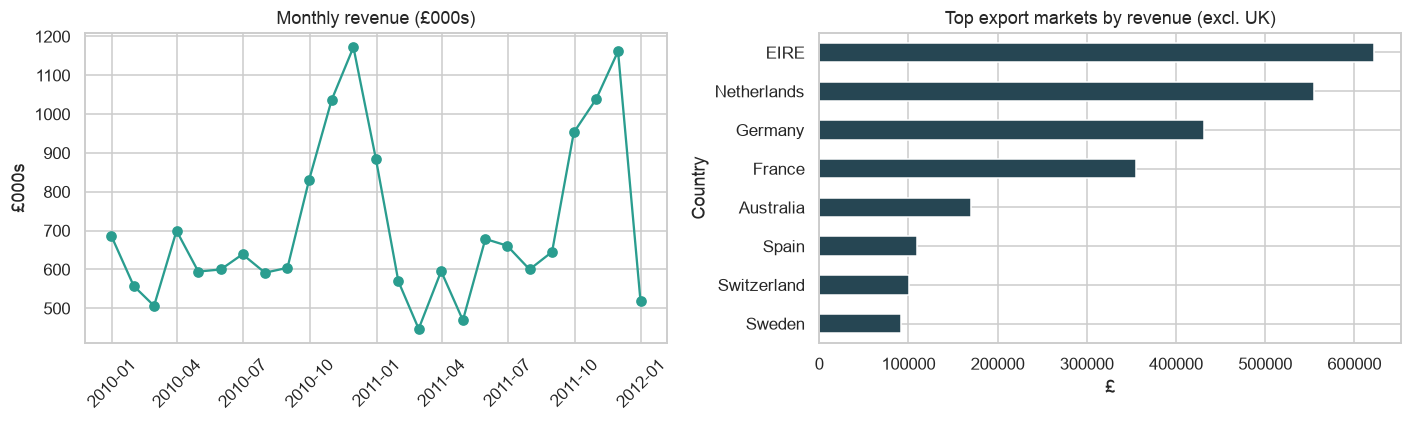

UK share of revenue: 83%


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
# Monthly revenue trend
monthly = df.set_index("InvoiceDate")["Revenue"].resample("ME").sum() / 1e3
ax[0].plot(monthly.index, monthly.values, marker="o", color="#2a9d8f")
ax[0].set_title("Monthly revenue (£000s)"); ax[0].set_ylabel("£000s"); ax[0].tick_params(axis='x', rotation=45)
# Top countries by revenue (excl. UK to see the rest)
by_country = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False)
by_country.drop("United Kingdom").head(8).iloc[::-1].plot.barh(ax=ax[1], color="#264653")
ax[1].set_title("Top export markets by revenue (excl. UK)"); ax[1].set_xlabel("£")
plt.tight_layout(); plt.savefig(IMG / "eda_overview.png", bbox_inches="tight"); plt.show()
print(f"UK share of revenue: {by_country['United Kingdom']/by_country.sum()*100:.0f}%")

## 4. Framing CLV as a supervised problem
CLV prediction needs a **time split**, not a random one — we must only use the *past* to predict the *future*.

- **Observation window** (features): all transactions up to a cutoff date.
- **Target window** (label): total spend in the **6 months after** the cutoff. Customers who don't return get a target of **£0** — capturing churn is part of the job.

We set the cutoff 6 months before the last date in the data.

In [5]:
max_date = df["InvoiceDate"].max().normalize()
cutoff = max_date - pd.DateOffset(months=6)
obs = df[df["InvoiceDate"] <= cutoff].copy()
future = df[df["InvoiceDate"] > cutoff].copy()
print(f"Observation window: {obs['InvoiceDate'].min().date()} .. {cutoff.date()}")
print(f"Target window:      {cutoff.date()} .. {max_date.date()} (6 months)")

Observation window: 2009-12-01 .. 2011-06-09
Target window:      2011-06-09 .. 2011-12-09 (6 months)


## 5. Feature engineering (RFM and beyond)
For every customer active in the observation window we engineer behavioural features — the classic **Recency, Frequency, Monetary** trio plus tenure, basket, product-variety and cadence signals.

In [6]:
g = obs.groupby("Customer ID")
feat = pd.DataFrame({
    "recency_days":      (cutoff - g["InvoiceDate"].max()).dt.days,
    "tenure_days":       (cutoff - g["InvoiceDate"].min()).dt.days,
    "frequency":         g["Invoice"].nunique(),
    "monetary_total":    g["Revenue"].sum(),
    "total_quantity":    g["Quantity"].sum(),
    "distinct_products": g["StockCode"].nunique(),
    "avg_unit_price":    g["Price"].mean(),
})
feat["avg_basket_value"]    = feat["monetary_total"] / feat["frequency"]
feat["avg_items_per_order"] = feat["total_quantity"] / feat["frequency"]
feat["purchase_rate"]       = feat["frequency"] / (feat["tenure_days"] + 1)
feat["is_uk"] = (obs.groupby("Customer ID")["Country"]
                    .agg(lambda s: s.mode().iloc[0]) == "United Kingdom").astype(int)
feat.head()

,recency_days,tenure_days,frequency,monetary_total,total_quantity,distinct_products,avg_unit_price,avg_basket_value,avg_items_per_order,purchase_rate,is_uk
Customer ID,,,,,,,,,,,
12346,141,541,12,77556.46,74285,27,6.100000,6463.038333,6190.416667,0.022140,1
12347,62,220,4,3146.75,1945,90,2.503226,786.687500,486.250000,0.018100,0
12348,64,254,4,1709.40,2497,25,3.137500,427.350000,624.250000,0.015686,0
12349,223,405,3,2671.14,993,90,8.581765,890.380000,331.000000,0.007389,0
12350,126,126,1,334.40,197,17,3.841176,334.400000,197.000000,0.007874,0


### Build the target: next-6-month spend (0 for customers who don't return)

Modeling customers: 4,966 | returned in target window: 52%
count      4966.0
mean        931.5
std        5633.2
min           0.0
25%           0.0
50%          93.4
75%         690.0
max      184015.7


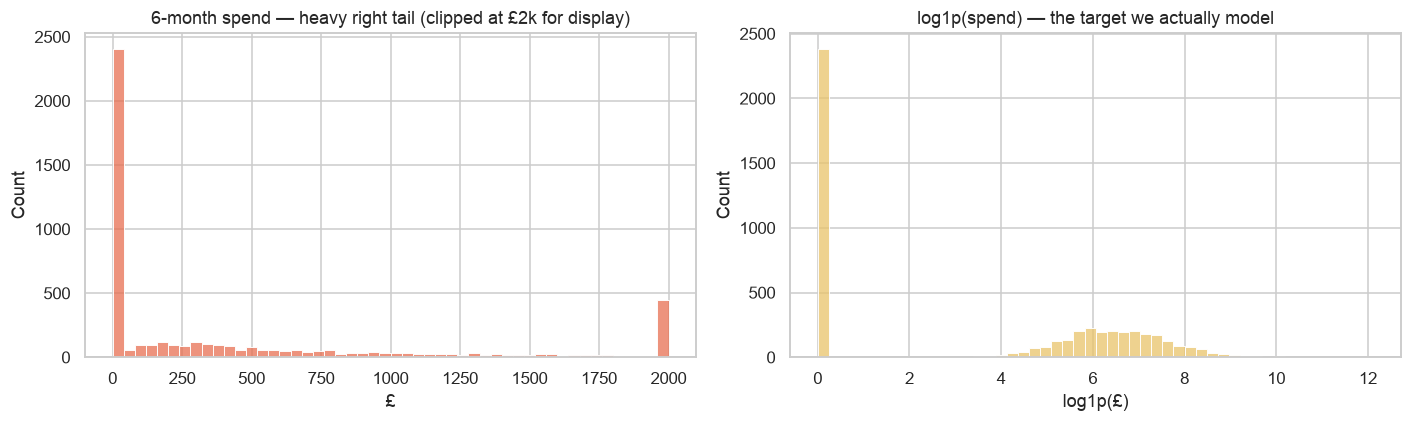

In [7]:
future_spend = future.groupby("Customer ID")["Revenue"].sum()
feat["target_6m_spend"] = feat.index.map(future_spend).fillna(0.0)
returned = (feat["target_6m_spend"] > 0).mean() * 100
print(f"Modeling customers: {len(feat):,} | returned in target window: {returned:.0f}%")
print(feat["target_6m_spend"].describe().round(1).to_string())

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(feat["target_6m_spend"].clip(upper=2000), bins=50, ax=ax[0], color="#e76f51")
ax[0].set_title("6-month spend — heavy right tail (clipped at £2k for display)"); ax[0].set_xlabel("£")
sns.histplot(np.log1p(feat["target_6m_spend"]), bins=50, ax=ax[1], color="#e9c46a")
ax[1].set_title("log1p(spend) — the target we actually model"); ax[1].set_xlabel("log1p(£)")
plt.tight_layout(); plt.savefig(IMG / "target_distribution.png", bbox_inches="tight"); plt.show()

## 6. Modelling
CLV is **heavily right-skewed** (most customers spend little; a few spend a fortune), so we model **`log1p(spend)`** for stability and transform predictions back to £ for evaluation. We hold out 20% of customers as a test set.

In [8]:
FEATURES = ["recency_days","tenure_days","frequency","monetary_total","total_quantity",
            "distinct_products","avg_unit_price","avg_basket_value","avg_items_per_order",
            "purchase_rate","is_uk"]
X, y = feat[FEATURES], feat["target_6m_spend"]
y_log = np.log1p(y)
X_tr, X_te, y_tr, y_te, ylog_tr, ylog_te = train_test_split(X, y, y_log, test_size=0.2, random_state=42)

def evaluate(name, model, log=True):
    model.fit(X_tr, ylog_tr if log else y_tr)
    pred = np.clip(np.expm1(model.predict(X_te)) if log else model.predict(X_te), 0, None)
    mae, rmse, r2 = (mean_absolute_error(y_te, pred),
                     np.sqrt(mean_squared_error(y_te, pred)), r2_score(y_te, pred))
    print(f"{name:22} MAE £{mae:7.0f} | RMSE £{rmse:8.0f} | R2 {r2:6.3f}")
    return model, pred

### 6a. Baseline: Linear Regression
A linear model is the honest starting point — and it **fails badly here** (a large negative R²). The heavy-tailed target and outlier whales break the squared-error fit, which is exactly why a tree-based model is warranted.

In [9]:
_lin, _ = evaluate("Linear Regression", LinearRegression())

Linear Regression      MAE £   2931 | RMSE £   62207 | R2 -118.109


### 6b. XGBoost Regressor (+ 5-fold cross-validation)

In [10]:
xgb_model, xpred = evaluate("XGBoost", xgb.XGBRegressor(
    n_estimators=400, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8, random_state=42))
cv = cross_val_score(xgb.XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8, random_state=42),
        X, y_log, cv=KFold(5, shuffle=True, random_state=42), scoring="r2")
print(f"\nXGBoost 5-fold CV R2 (log target): {cv.mean():.3f} +/- {cv.std():.3f}")
print("Note: single-split R2 in £-space is inflated by a few whale customers;")
print("the cross-validated log-space R2 (~0.35) is the more honest stability figure.")

XGBoost                MAE £    600 | RMSE £    3182 | R2  0.688



XGBoost 5-fold CV R2 (log target): 0.348 +/- 0.025
Note: single-split R2 in £-space is inflated by a few whale customers;
the cross-validated log-space R2 (~0.35) is the more honest stability figure.


## 7. Why the model decides what it does — SHAP
A prediction of "£200" is only useful if marketing knows *why*. SHAP attributes each prediction to its drivers, giving a behavioural hierarchy of value.

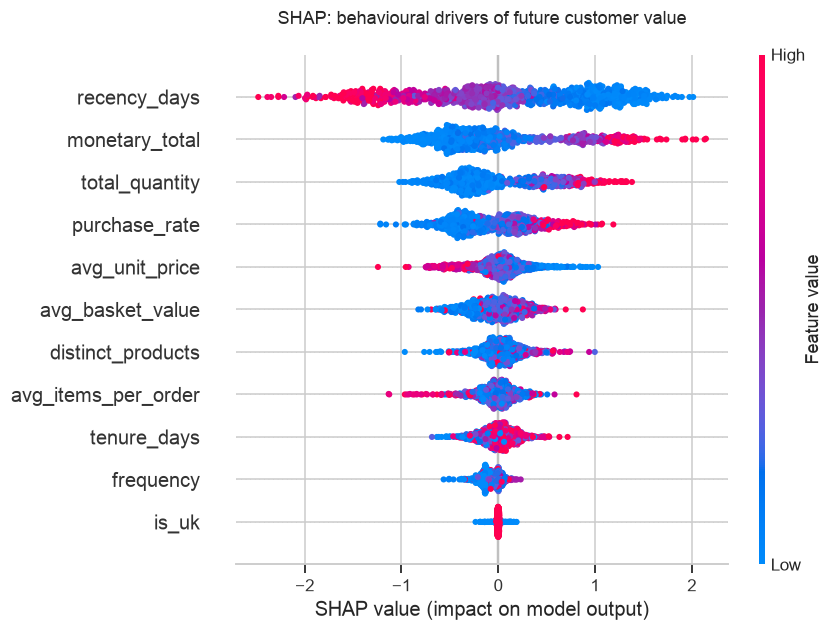

In [11]:
explainer = shap.TreeExplainer(xgb_model)
Xs = X_te.sample(min(1500, len(X_te)), random_state=42)
shap_values = explainer.shap_values(Xs)
plt.figure()
shap.summary_plot(shap_values, Xs, show=False)
plt.title("SHAP: behavioural drivers of future customer value", pad=20)
plt.tight_layout(); plt.savefig(IMG / "shap_summary.png", bbox_inches="tight"); plt.show()

## 8. Business impact — does targeting by predicted CLV actually work?
The real test isn't R² — it's whether ranking customers by predicted CLV concentrates *actual* future revenue. We bucket the test customers into deciles by prediction and measure the actual spend each decile delivered.

Top 10% predicted customers capture 63% of actual future revenue (random ~10%).
Top 20% predicted customers capture 75% of actual future revenue.


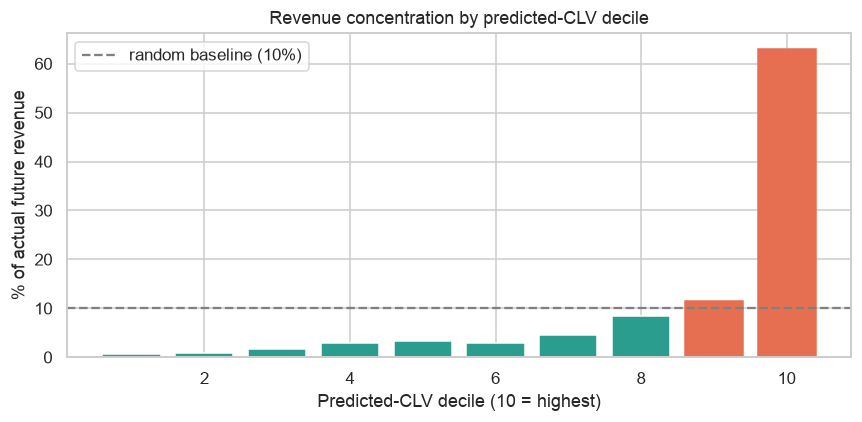

In [12]:
res = pd.DataFrame({"actual": y_te.values, "pred": xpred})
res["decile"] = pd.qcut(res["pred"].rank(method="first"), 10, labels=False)
capture = res.groupby("decile")["actual"].sum() / res["actual"].sum() * 100
top10, top20 = capture[9], capture[[8,9]].sum()
print(f"Top 10% predicted customers capture {top10:.0f}% of actual future revenue (random ~10%).")
print(f"Top 20% predicted customers capture {top20:.0f}% of actual future revenue.")

plt.figure(figsize=(8,4))
bars = plt.bar(range(1,11), capture.values, color="#2a9d8f")
bars[-1].set_color("#e76f51"); bars[-2].set_color("#e76f51")
plt.axhline(10, ls="--", color="grey", label="random baseline (10%)")
plt.xlabel("Predicted-CLV decile (10 = highest)"); plt.ylabel("% of actual future revenue")
plt.title("Revenue concentration by predicted-CLV decile"); plt.legend()
plt.tight_layout(); plt.savefig(IMG / "revenue_capture_by_decile.png", bbox_inches="tight"); plt.show()

## 9. Conclusion, limitations & next steps

**What works:** XGBoost on RFM-style behavioural features predicts 6-month CLV with MAE ≈ £600 and, more importantly, produces a ranking where the **top decile captures ~63% of actual future revenue** — a targeting list a CRM team can act on immediately. SHAP shows monetary total, quantity, recency and purchase cadence are the dominant behavioural drivers.

**Honest limitations:**
- CLV is intrinsically hard to predict at the individual level — the cross-validated log-space R² (~0.35) reflects that, and the £-space R² is inflated by a handful of "whale" customers. MAE and the decile-capture metric are the more trustworthy signals here.
- A single 6-month window is used; a rolling/multi-window validation would be more robust.
- No product-category or seasonality features yet.

**Next steps:** rolling-window validation, probabilistic CLV (e.g. BG/NBD + Gamma-Gamma) as a benchmark, and a small Streamlit app that takes a customer's RFM profile and returns predicted CLV + SHAP explanation.

---
### 🎤 Interview talking points
- *"Why did linear regression get R² of −118?"* — heavy-tailed target + outlier whales; squared error is dominated by them. Motivates trees + a log target.
- *"Why report MAE and decile-capture instead of R²?"* — with a heavy tail, R² is unstable across splits; MAE and revenue-capture are robust and business-meaningful.
- *"How did you avoid leakage?"* — strict time split: features from the observation window only, target from a disjoint future window.
- *"What does the model actually tell marketing?"* — SHAP ranks the behaviours driving value, and the decile chart says "target these 10% to reach ~63% of future revenue."
